|                |   |
:----------------|---|
| **Nombre**     Elisa Aguirre|   |
| **Fecha**      27/04/25|   |
| **Expediente** 738894 |   |

# T09 - Resampling

## Ejercicio 1

1.Using basic statistical properties of the variance, as well as single variable calculus, derive(5.6). In other words, prove that given by
(5.6)does indeed minimize

$$Var(\alpha X + (1-\alpha)Y)$$

Primero usamos la propiedad de la varianza para una combinación lineal:

$$
Var(\alpha X + (1-\alpha)Y)
=
\alpha^2 Var(X) + (1-\alpha)^2 Var(Y) + 2\alpha(1-\alpha)Cov(X,Y)
$$

Como queremos encontrar el valor de $\alpha$ que minimiza la varianza, derivamos con respecto a $\alpha$ e igualamos a cero:

$$
\frac{d}{d\alpha} Var(\alpha X + (1-\alpha)Y) = 0
$$

Al resolver la derivada, se obtiene:

$$
\alpha =
\frac{Var(Y)-Cov(X,Y)}
{Var(X)+Var(Y)-2Cov(X,Y)}
$$

Por lo tanto, este valor de $\alpha$ es el que minimiza la varianza de la combinación lineal $\alpha X + (1-\alpha)Y$.

En palabras más simples, $\alpha$ representa el peso que se le da a $X$ dentro de la combinación. El objetivo es elegir ese peso de manera que la mezcla entre $X$ y $Y$ tenga la menor variabilidad posible.

## Exercise 2

We will now derive the probability that a given observation is part of a bootstrap sample. Suppose that we obtain a bootstrap sample from a set of $n$ observations.

---

### a)

What is the probability that the first bootstrap observation is not the $j$th observation from the original sample? Justify your answer.

La probabilidad de que la primera observación bootstrap **no** sea la observación $j$ de la muestra original es:

$$
1 - \frac{1}{n}
$$

Esto se debe a que la probabilidad de elegir la observación $j$ es $\frac{1}{n}$, entonces la probabilidad de no elegirla es el complemento.

---

### b)

What is the probability that the second bootstrap observation is not the $j$th observation from the original sample?

La probabilidad de que la segunda observación bootstrap **no** sea la observación $j$ también es:

$$
1 - \frac{1}{n}
$$

Cada extracción se hace con reemplazo, por lo que las probabilidades no cambian.

---

### c)

Argue that the probability that the $j$th observation is not in the bootstrap sample is $(1 - 1/n)^n$.

Como se realizan $n$ extracciones independientes, la probabilidad de que la observación $j$ no aparezca en ninguna es:

$$
\left(1 - \frac{1}{n}\right)^n
$$

---

### d)

When $n = 5$, what is the probability that the $j$th observation is in the bootstrap sample?

Primero calculamos la probabilidad de que **no aparezca**:

$$
(0.8)^5 = 0.32768
$$

Entonces la probabilidad de que **sí aparezca** es:

$$
1 - 0.32768 = 0.6723
$$

---

### e)

When $n = 100$, what is the probability that the $j$th observation is in the bootstrap sample?

$$
1 - (0.99)^{100} \approx 0.634
$$

---

### f)

When $n = 10,000$, what is the probability that the $j$th observation is in the bootstrap sample?

$$
1 - \left(1 - \frac{1}{10000}\right)^{10000}
$$

Este valor se aproxima a:

$$
1 - e^{-1} \approx 0.632
$$

---

### g)

Create a plot that displays, for each integer value of $n$ from 1 to 100,000, the probability that the $j$th observation is in the bootstrap sample. Comment on what you observe.

Para cada valor de $n$, la probabilidad de que la observación $j$ **sí aparezca** en la muestra bootstrap es:

$$
1 - \left(1 - \frac{1}{n}\right)^n
$$

Usamos esta fórmula porque anteriormente vimos que:

$$
\left(1 - \frac{1}{n}\right)^n
$$

representa la probabilidad de que la observación $j$ **no** aparezca en la muestra bootstrap.

Entonces, el complemento representa la probabilidad de que **sí aparezca**.


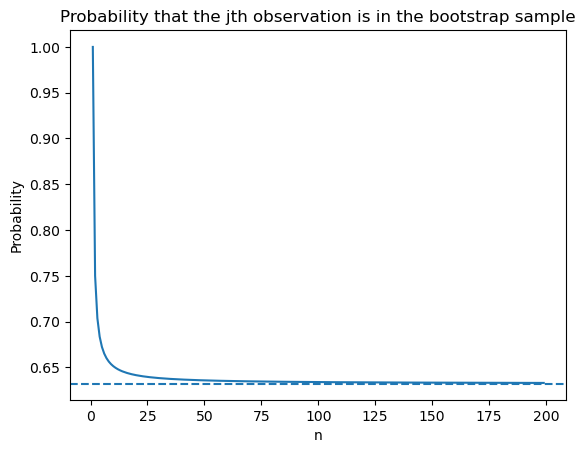

In [7]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(1, 200)

prob = 1 - (1 - 1/n)**n

plt.plot(n, prob)
plt.axhline(0.632, linestyle='--')
plt.xlabel("n")
plt.ylabel("Probability")
plt.title("Probability that the jth observation is in the bootstrap sample")
plt.show()

Al observar la gráfica, se puede ver que la probabilidad se acerca rápidamente a un valor aproximado de:

$$
0.632
$$

Esto significa que, aunque el tamaño de la muestra aumente, la probabilidad de que una observación específica aparezca al menos una vez en una muestra bootstrap se estabiliza alrededor de **63.2%**.

Por lo tanto, en una muestra bootstrap, no necesariamente aparecen todas las observaciones originales; aproximadamente el 63.2% aparece al menos una vez.

---
### h)

We will now investigate numerically the probability that a bootstrap sample of size $n = 100$ contains the $j$th observation. Here $j = 4$.

We first create an array `store` with values that will subsequently be overwritten using the function `np.empty()`. We then repeatedly create bootstrap samples, and each time we record whether or not the fifth observation is contained in the bootstrap sample.

In [8]:
rng = np.random.default_rng(10)
store = np.empty(10000)

for i in range(10000):
    store[i] = np.sum(rng.choice(100,100, replace=True) == 4) > 0

np.mean(store)

np.float64(0.6362)

Aunque el código mostrado en el libro parece no incluir explícitamente el tamaño de la muestra, en realidad se refiere a una muestra bootstrap de tamaño $n=100$.

Por lo tanto, en la implementación práctica en Python es necesario especificar este tamaño como:

```python
rng.choice(100, 100, replace=True)

El resultado obtenido es cercano a:

$$
0.63
$$

Esto coincide con el resultado teórico:

$$
1 - \left(1 - \frac{1}{100}\right)^{100}
$$

Por lo tanto, la simulación confirma que la probabilidad de que la observación $j = 4$ aparezca en una muestra bootstrap de tamaño $n = 100$ es aproximadamente 63.2%.

En conclusión, el resultado numérico es consistente con la probabilidad teórica.

## Exercise 3

We now review $k$-fold cross-validation.

---

### a)

Explain how $k$-fold cross-validation is implemented.

En el método de $k$-fold cross-validation, el conjunto de datos se divide en $k$ subconjuntos (folds) de tamaño aproximadamente igual.

El procedimiento es el siguiente:

1. Se selecciona uno de los folds como conjunto de validación.
2. El modelo se entrena con los $k-1$ folds restantes.
3. Se calcula el error de predicción en el fold de validación.
4. Este proceso se repite $k$ veces, utilizando cada fold una vez como conjunto de validación.
5. Finalmente, se promedian los $k$ errores obtenidos para estimar el error de test.

---

### b)

What are the advantages and disadvantages of $k$-fold cross-validation relative to:

---

#### i. The validation set approach?

**Ventajas:**

- Proporciona una estimación más precisa del error de test, ya que utiliza una mayor proporción de los datos para entrenar el modelo.
- Reduce la variabilidad asociada a una sola partición de los datos.

**Desventajas:**

- Es más costoso computacionalmente, ya que el modelo se ajusta $k$ veces.

---

#### ii. LOOCV?

(Leave-One-Out Cross-Validation)

**Ventajas:**

- Es menos costoso computacionalmente que LOOCV, especialmente cuando el tamaño de la muestra es grande.
- Presenta menor varianza en la estimación del error en comparación con LOOCV.

**Desventajas:**

- Puede tener un poco más de sesgo que LOOCV, ya que en cada iteración se entrena con una fracción ligeramente menor de los datos.

## Exercise 4

Suppose that we use some statistical learning method to make a prediction for the response $Y$ for a particular value of the predictor $X$. Carefully describe how we might estimate the standard deviation of our prediction.

Para estimar la desviación estándar de una predicción, podemos usar el método bootstrap, como se explica en el capítulo de resampling.

La idea sería repetir muchas veces el proceso de remuestreo, ajuste del modelo y predicción.

El procedimiento sería:

1. Tomar muchas muestras bootstrap a partir del conjunto de datos original.
2. Para cada muestra bootstrap, ajustar el mismo método de statistical learning.
3. Usar cada modelo ajustado para predecir el valor de $Y$ para el mismo valor específico de $X$.
4. Guardar todas las predicciones obtenidas.
5. Calcular la desviación estándar de esas predicciones.

De esta forma, la desviación estándar de las predicciones bootstrap sirve como una estimación de la variabilidad de nuestra predicción.

En conclusión, si las predicciones cambian mucho entre muestras bootstrap, entonces la desviación estándar será alta. Si las predicciones son muy parecidas, entonces la desviación estándar será baja.

## Exercise 5

In Chapter 4, we used logistic regression to predict the probability of `default` using `income` and `balance` on the `Default` data set. We will now estimate the test error of this logistic regression model using the validation set approach. Do not forget to set a random seed before beginning your analysis.

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df=pd.read_csv(r"C:\Users\elisa\Downloads\Default.csv")
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


### a)

Fit a logistic regression model that uses `income` and `balance` to predict `default`.

Se ajusta un modelo de regresión logística usando `income` y `balance` como variables predictoras, y `default` como variable respuesta.

In [11]:
X = df[["income", "balance"]]
y = df["default"]

modelo = LogisticRegression()
modelo.fit(X, y)

modelo.intercept_, modelo.coef_

(array([-11.54046792]), array([[2.08089741e-05, 5.64710265e-03]]))

### b)

Using the validation set approach, estimate the test error of this model.

In [12]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.5, random_state=1
)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

prob = modelo.predict_proba(X_valid)[:,1]
pred = np.where(prob > 0.5, "Yes", "No")

error = np.mean(pred != y_valid)
error

np.float64(0.025)

### c)

Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained.

Se repite el procedimiento anterior tres veces, usando diferentes particiones de entrenamiento y validación.

In [13]:
semillas = [2, 3, 4]
errores = []

for semilla in semillas:
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.5, random_state=semilla
    )
    
    modelo = LogisticRegression(max_iter=1000)
    modelo.fit(X_train, y_train)
    
    prob = modelo.predict_proba(X_valid)[:, 1]
    pred = np.where(prob > 0.5, "Yes", "No")
    
    error = np.mean(pred != y_valid)
    errores.append(error)

errores

[np.float64(0.0248), np.float64(0.0248), np.float64(0.0238)]

### d)

Now consider a logistic regression model that predicts the probability of `default` using `income`, `balance`, and a dummy variable for `student`. Estimate the test error for this model using the validation set approach. Comment on whether or not including a dummy variable for `student` leads to a reduction in the test error rate.

Ahora se ajusta un modelo de regresión logística usando `income`, `balance` y una variable dummy para `student`.

In [14]:
X_student = pd.get_dummies(df[["income", "balance", "student"]], drop_first=True)
y = df["default"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_student, y, test_size=0.5, random_state=1
)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

prob = modelo.predict_proba(X_valid)[:, 1]
pred = np.where(prob > 0.5, "Yes", "No")

error_student = np.mean(pred != y_valid)
error_student

np.float64(0.0262)

El error del modelo con `income` y `balance` fue:

$$
0.025
$$

El error del modelo incluyendo `student` fue:

$$
0.0262
$$

Al comparar ambos errores, se observa que incluir la variable `student` no reduce el error de test.

## Exercise 6

We continue to consider the use of a logistic regression model to predict the probability of `default` using `income` and `balance` on the `Default` data set. In particular, we will now compute estimates for the standard errors of the `income` and `balance` logistic regression coefficients in two different ways: (1) using the bootstrap, and (2) using the standard formula for computing the standard errors in the `sm.GLM()` function. Do not forget to set a random seed before beginning your analysis.

In [15]:
import statsmodels.api as sm

### a)

Using the `summarize()` and `sm.GLM()` functions, determine the estimated standard errors for the coefficients associated with `income` and `balance` in a multiple logistic regression model that uses both predictors.

In [16]:
y_num = df["default"].map({"No": 0, "Yes": 1})

X_glm = df[["income", "balance"]]
X_glm = sm.add_constant(X_glm)

modelo_glm = sm.GLM(y_num, X_glm, family=sm.families.Binomial())
resultado_glm = modelo_glm.fit()

resultado_glm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Sun, 03 May 2026   Deviance:                       1579.0
Time:                        23:12:04   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.000     -12.393     -10.688
income      2.081e-05   4.99e-06      4.174      0.000     1.1e-05    3.06e-05
balance        0.0056      0.000     24.835      0.000       0.005       0.006
==============================================================================
"""

In [17]:
resultado_glm.bse

const      0.434772
income     0.000005
balance    0.000227
dtype: float64

### b)

Write a function, `boot_fn()`, that takes as input the `Default` data set as well as an index of the observations, and that outputs the coefficient estimates for `income` and `balance` in the multiple logistic regression model.

In [18]:
def boot_fn(data, idx):
    data_boot = data.iloc[idx]
    
    y_boot = data_boot["default"].map({"No": 0, "Yes": 1})
    X_boot = data_boot[["income", "balance"]]
    X_boot = sm.add_constant(X_boot)
    
    modelo_boot = sm.GLM(y_boot, X_boot, family=sm.families.Binomial())
    resultado_boot = modelo_boot.fit()
    
    return resultado_boot.params

In [19]:
boot_fn(df, np.arange(df.shape[0]))

const     -11.540468
income      0.000021
balance     0.005647
dtype: float64

### c)

Following the bootstrap example in the lab, use your `boot_fn()` function to estimate the standard errors of the logistic regression coefficients for `income` and `balance`.

In [20]:
rng = np.random.default_rng(1)

B = 1000
coeficientes = np.empty((B, 3))

for i in range(B):
    idx = rng.choice(df.shape[0], df.shape[0], replace=True)
    coeficientes[i] = boot_fn(df, idx)

coeficientes_boot = pd.DataFrame(
    coeficientes,
    columns=["const", "income", "balance"]
)

coeficientes_boot.std()

const      0.438323
income     0.000005
balance    0.000226
dtype: float64

### d)

Comment on the estimated standard errors obtained using the `sm.GLM()` function and using the bootstrap.

Se comparan los errores estándar obtenidos con `sm.GLM()` y con bootstrap.

In [21]:
comparacion = pd.DataFrame({
    "GLM": resultado_glm.bse,
    "Bootstrap": coeficientes_boot.std()
})

comparacion

,GLM,Bootstrap
const,0.434772,0.438323
income,0.000005,0.000005
balance,0.000227,0.000226


Los errores estándar obtenidos con `sm.GLM()` y con bootstrap son muy similares para todos los coeficientes.

Esto indica que ambos métodos proporcionan estimaciones consistentes de la variabilidad de los coeficientes del modelo.

Por lo tanto, el método bootstrap confirma los resultados obtenidos mediante la fórmula estándar utilizada por `sm.GLM()`.

## Exercise 7

In Sections 5.1.2 and 5.1.3, we saw that the `cross_validate()` function can be used in order to compute the LOOCV test error estimate. Alternatively, one could compute those quantities using just `sm.GLM()` and the `predict()` method of the fitted model within a for loop. You will now take this approach in order to compute the LOOCV error for a simple logistic regression model on the `Weekly` data set.

In [22]:
Weekly = pd.read_csv(r"C:\Users\elisa\Downloads\Weekly.csv")
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


### a)

Fit a logistic regression model that predicts `Direction` using `Lag1` and `Lag2`.

In [23]:
y = Weekly["Direction"].map({"Down": 0, "Up": 1})

X = Weekly[["Lag1", "Lag2"]]
X = sm.add_constant(X)

modelo = sm.GLM(y, X, family=sm.families.Binomial())
resultado = modelo.fit()

resultado.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1086
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -744.11
Date:                Sun, 03 May 2026   Deviance:                       1488.2
Time:                        23:28:40   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007303
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2212      0.061      3.599      0.000       0.101       0.342
Lag1          -0.0387      0.026     -1.477      0.140      -0.090       0.013
Lag2           0.0602      0.027      2.270      0.023       0.008       0.112
==============================================================================
"""

### b)

Fit a logistic regression model that predicts `Direction` using `Lag1` and `Lag2` using all but the first observation.

In [24]:
y_b = y.iloc[1:]
X_b = X.iloc[1:]

modelo_b = sm.GLM(y_b, X_b, family=sm.families.Binomial())
resultado_b = modelo_b.fit()

resultado_b.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1088
Model:                            GLM   Df Residuals:                     1085
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.26
Date:                Sun, 03 May 2026   Deviance:                       1486.5
Time:                        23:29:46   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007373
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2232      0.061      3.630      0.000       0.103       0.344
Lag1          -0.0384      0.026     -1.466      0.143      -0.090       0.013
Lag2           0.0608      0.027      2.291      0.022       0.009       0.113
==============================================================================
"""

### c)

Use the model from (b) to predict the direction of the first observation. Was this observation correctly classified?

In [25]:
prob_1 = resultado_b.predict(X.iloc[[0]])
prob_1

0    0.571392
dtype: float64

In [26]:
pred_1 = "Up" if prob_1.iloc[0] > 0.5 else "Down"
pred_1

'Up'

In [27]:
Weekly["Direction"].iloc[0]

'Down'

La probabilidad estimada de que la primera observación tenga `Direction = "Up"` fue:

$$
0.571392
$$

Como esta probabilidad es mayor que 0.5, se clasifica la primera observación como:

$$
\text{Up}
$$

Sin embargo, el valor real de la primera observación es:

$$
\text{Down}
$$

Por lo tanto, la primera observación no fue clasificada correctamente.

### d)

Write a for loop from $i = 1$ to $i = n$, where $n$ is the number of observations in the data set, that performs each of the following steps:

i. Fit a logistic regression model using all but the $i$th observation to predict `Direction` using `Lag1` and `Lag2`.

ii. Compute the posterior probability of the market moving up for the $i$th observation.

iii. Use the posterior probability for the $i$th observation in order to predict whether or not the market moves up.

iv. Determine whether or not an error was made in predicting the direction for the $i$th observation.

In [28]:
n = Weekly.shape[0]
errores = np.empty(n)

for i in range(n):
    y_train = y.drop(i)
    X_train = X.drop(i)
    
    X_test = X.iloc[[i]]
    real = Weekly["Direction"].iloc[i]
    
    modelo_i = sm.GLM(y_train, X_train, family=sm.families.Binomial())
    resultado_i = modelo_i.fit()
    
    prob_i = resultado_i.predict(X_test)
    
    pred_i = "Up" if prob_i.iloc[0] > 0.5 else "Down"
    
    errores[i] = 1 if pred_i != real else 0

errores

array([1., 1., 0., ..., 0., 0., 0.])

El vector `errores` contiene un 1 cuando la observación fue clasificada incorrectamente y un 0 cuando fue clasificada correctamente.

Este procedimiento corresponde al método LOOCV, ya que en cada iteración se deja fuera una observación, se ajusta el modelo con las demás observaciones y después se predice la observación que fue excluida.

### e)

Take the average of the $n$ numbers obtained in (d) in order to obtain the LOOCV estimate for the test error. Comment on the results.

In [29]:
loocv_error = np.mean(errores)
loocv_error

np.float64(0.44995408631772266)

El error estimado mediante LOOCV es:

$$
0.44995
$$

Este valor representa la proporción promedio de observaciones que fueron clasificadas incorrectamente al dejar una observación fuera en cada iteración.

Por lo tanto, el modelo comete errores en aproximadamente el 45% de las observaciones.

## Exercise 8

We will now perform cross-validation on a simulated data set.

### a)

Generate a simulated data set as follows:

In [30]:
rng = np.random.default_rng(1)

x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

In this data set, what is $n$ and what is $p$? Write out the model used to generate the data in equation form.

En este caso:

- $n = 100$ (número de observaciones)
- $p = 1$ (una sola variable predictora $X$)

El modelo utilizado para generar los datos es:

$$
Y = X - 2X^2 + \varepsilon
$$

### b)

Create a scatterplot of $X$ against $Y$. Comment on what you find.

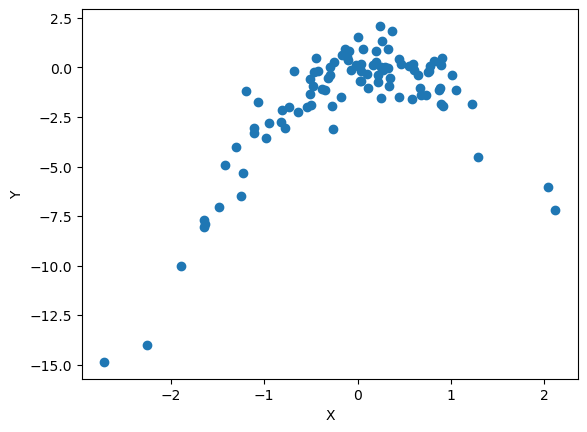

In [31]:
plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Se observa una relación no lineal entre $X$ y $Y$, con forma aproximadamente cuadrática.

En particular, $Y$ tiende a aumentar para valores pequeños de $X$ y luego disminuir, lo cual es consistente con un modelo que incluye un término $X^2$ negativo.

### c)

Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

i. $Y = \beta_0 + \beta_1 X + \varepsilon$  
ii. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon$  
iii. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon$  
iv. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \beta_4 X^4 + \varepsilon$

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

X = pd.DataFrame({"x": x})

def loocv_error(X, y):
    loo = LeaveOneOut()
    errores = []
    
    for train, test in loo.split(X):
        X_train, X_test = X.iloc[train], X.iloc[test]
        y_train, y_test = y[train], y[test]
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        
        errores.append((y_test - pred)**2)
    
    return np.mean(errores)

# modelos
X1 = X[["x"]]
X2 = pd.DataFrame({"x": x, "x2": x**2})
X3 = pd.DataFrame({"x": x, "x2": x**2, "x3": x**3})
X4 = pd.DataFrame({"x": x, "x2": x**2, "x3": x**3, "x4": x**4})

e1 = loocv_error(X1, y)
e2 = loocv_error(X2, y)
e3 = loocv_error(X3, y)
e4 = loocv_error(X4, y)

e1, e2, e3, e4

(np.float64(6.633029839181983),
 np.float64(1.1229368563419684),
 np.float64(1.3017965489358867),
 np.float64(1.3323942694179325))

El modelo cuadrático (que incluye $X^2$) tiene el menor error LOOCV.

Esto indica que es el modelo que mejor se ajusta a los datos.

El modelo lineal presenta un error mucho mayor, lo que confirma que una relación lineal no es adecuada.

Los modelos de mayor grado no mejoran el error, lo que sugiere que no es necesario agregar términos adicionales.

### d)

Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?

In [36]:
rng = np.random.default_rng(2)

x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

In [37]:
X = pd.DataFrame({"x": x})

def loocv_error(X, y):
    loo = LeaveOneOut()
    errores = []
    
    for train, test in loo.split(X):
        X_train, X_test = X.iloc[train], X.iloc[test]
        y_train, y_test = y[train], y[test]
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        
        errores.append((y_test - pred)**2)
    
    return np.mean(errores)

# modelos
X1 = X[["x"]]
X2 = pd.DataFrame({"x": x, "x2": x**2})
X3 = pd.DataFrame({"x": x, "x2": x**2, "x3": x**3})
X4 = pd.DataFrame({"x": x, "x2": x**2, "x3": x**3, "x4": x**4})

e1 = loocv_error(X1, y)
e2 = loocv_error(X2, y)
e3 = loocv_error(X3, y)
e4 = loocv_error(X4, y)

e1, e2, e3, e4

(np.float64(7.560603694358579),
 np.float64(0.9840371744582579),
 np.float64(0.9682355765918602),
 np.float64(0.9659585554875683))

Los resultados no son exactamente iguales a los del inciso (c), porque se generaron nuevos datos con otra semilla aleatoria.

Sin embargo, el comportamiento general es parecido: el modelo lineal tiene un error mucho más alto y los modelos con términos cuadráticos o mayores tienen errores mucho menores.

### e)

Which of the models in (c) had the smallest LOOCV error? Explain what this says about the expected test error.

El modelo con menor error LOOCV es el modelo de grado 4.

Sin embargo, la diferencia entre los modelos de grado 2, 3 y 4 es muy pequeña. Por lo tanto, aunque el grado 4 tiene el menor error en esta simulación, el modelo cuadrático también es razonable porque coincide con la forma del modelo que generó los datos.

### f)

Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares.

In [38]:
for X_model in [X1, X2, X3, X4]:
    X_sm = sm.add_constant(X_model)
    modelo = sm.OLS(y, X_sm).fit()
    print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     18.15
Date:                Sun, 03 May 2026   Prob (F-statistic):           4.68e-05
Time:                        23:48:34   Log-Likelihood:                -238.27
No. Observations:                 100   AIC:                             480.5
Df Residuals:                      98   BIC:                             485.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8158      0.265     -6.857      0.0

Al ajustar los modelos mediante mínimos cuadrados, se observa que los coeficientes de $X$ y $X^2$ son estadísticamente significativos.

En el modelo cúbico, el coeficiente de $X^3$ no es significativo, y en el modelo de grado 4, los coeficientes de $X^3$ y $X^4$ tampoco son significativos.

Esto coincide con los resultados de LOOCV, ya que agregar términos de mayor grado no reduce de forma importante el error. Por lo tanto, el modelo cuadrático es suficiente para representar la relación entre $X$ y $Y$.

## Exercise 9

We will now consider the `Boston` housing data set, from the `ISLP` library.

In [39]:
Boston = pd.read_excel(r"C:\Users\elisa\Downloads\Boston Housing Dataset 1978.xlsx")
Boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### a)

Based on this data set, provide an estimate for the population mean of `medv`. Call this estimate $\hat{\mu}$.

In [57]:
mu_hat = Boston["MEDV"].mean()
mu_hat

np.float64(23.750442477876106)

La estimación de la media poblacional de `medv` es la media muestral:

$$
\hat{\mu} = \bar{x}
$$

### b)

Provide an estimate of the standard error of $\hat{\mu}$. Interpret this result.

In [58]:
se_mu = Boston["MEDV"].std() / np.sqrt(Boston.shape[0])
se_mu

np.float64(0.3915901080014807)

El error estándar de $\hat{\mu}$ se estima dividiendo la desviación estándar muestral entre la raíz cuadrada del número de observaciones:

$$
SE(\hat{\mu}) = \frac{s}{\sqrt{n}}
$$

Este valor mide la variabilidad esperada de la media muestral.

### c)

Now estimate the standard error of $\hat{\mu}$ using the bootstrap. How does this compare to your answer from (b)?

In [62]:
rng = np.random.default_rng(1)

medv = Boston["MEDV"].dropna().values
n = len(medv)

B = 1000
medias_boot = np.empty(B)

for i in range(B):
    muestra = rng.choice(medv, size=n, replace=True)
    medias_boot[i] = np.mean(muestra)

se_boot_mu = np.std(medias_boot)
se_boot_mu

np.float64(0.41186437010089005)

El error estándar estimado mediante bootstrap es muy similar al obtenido con la fórmula del inciso (b).

### d)

Based on your bootstrap estimate from (c), provide a 95% confidence interval for the mean of `medv`.

In [63]:
IC_mu = [mu_hat - 2 * se_boot_mu, mu_hat + 2 * se_boot_mu]
IC_mu

[np.float64(22.926713737674326), np.float64(24.574171218077886)]

El intervalo de confianza aproximado al 95% se calcula como:

$$
[\hat{\mu} - 2SE(\hat{\mu}), \hat{\mu} + 2SE(\hat{\mu})]
$$

### e)

Based on this data set, provide an estimate, $\hat{\mu}_{med}$, for the median value of `medv` in the population.

In [65]:
mu_med_hat = Boston["MEDV"].median()
mu_med_hat

21.95

### f)

Estimate the standard error of the median using the bootstrap. Comment on your findings.

In [66]:
rng = np.random.default_rng(1)
B = 1000
medianas_boot = np.empty(B)

for i in range(B):
    muestra = rng.choice(medv, size=n, replace=True)
    medianas_boot[i] = np.median(muestra)

se_boot_median = np.std(medianas_boot)
se_boot_median

np.float64(0.30146250181407325)

El bootstrap permite estimar el error estándar de la mediana, ya que no se usa una fórmula simple como en el caso de la media.

### g)

Based on this data set, provide an estimate for the tenth percentile of `medv`. Call this quantity $\hat{\mu}_{0.1}$.

In [67]:
mu_01_hat = np.percentile(Boston["MEDV"].dropna().values, 10)
mu_01_hat

np.float64(14.5)

La estimación del percentil 10 de `medv` se obtiene usando `np.percentile()`.

### h)

Use the bootstrap to estimate the standard error of $\hat{\mu}_{0.1}$. Comment on your findings.

In [68]:
rng = np.random.default_rng(1)
B = 1000
percentiles_boot = np.empty(B)

for i in range(B):
    muestra = rng.choice(medv, size=n, replace=True)
    percentiles_boot[i] = np.percentile(muestra, 10)

se_boot_percentile = np.std(percentiles_boot)
se_boot_percentile

np.float64(0.42094620071928424)

El error estándar bootstrap del percentil 10 mide la variabilidad de esta estimación.

Al igual que en el caso de la mediana, el bootstrap es útil porque permite estimar la variabilidad de estadísticos para los cuales no existe una fórmula simple.